# omol25_low combination energies for all adsorbates

In [1]:
from lzn.data_processing.extract_energies import *
from lzn.universal import *
from lzn.atoms_manipulate.construct_subads import read_mspa_frame

import pandas as pd
from matplotlib import pyplot as plt

/home/zining/miniconda3/envs/mlip/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
atoms ,rankings = read_mspa_frame("../05_mspa_substrates/tio12CDa_opt-pbe0_def2svpS_hsM.xyz", "Vsmax")
name_list = ["co_site"+str(rankings[2*i][0]) for i in range(len(rankings)//2)]
potential_list = [rankings[2*i][2] for i in range(len(rankings)//2)]
df_potentials = pd.DataFrame(list(zip(name_list, potential_list)), columns=["structures", "Vsmax"])
df_potentials

,structures,Vsmax
0,co_site36,124.49
1,co_site38,106.04
2,co_site40,61.55
3,co_site42,59.38
4,co_site44,49.99
5,co_site46,41.54
6,co_site48,39.96
7,co_site50,35.47
8,co_site52,26.76
9,co_site54,22.64


In [3]:
def traj_to_energies_df(data_dir, matching, col_name, name_start = 1, name_end = 3) -> pd.DataFrame:
    data_dir = to_path(data_dir)

    extract_name = lambda s, *args: '_'.join(s.stem.split("_")[name_start: name_end])

    e_list = batch_do(
        extract_ase_energy,
        data_dir,
        matching,
    )

    name_list = batch_do(
        extract_name,
        data_dir,
        matching,
    )

    df_inherent_mlip = pd.DataFrame(list(zip(name_list, e_list)), columns=["Structures", col_name])
    df_inherent_mlip

    return df_inherent_mlip


def glog_to_energies_df(data_dir, matching, col_name, name_start = 1, name_end = 3) -> pd.DataFrame:
    data_dir = to_path(data_dir)

    extract_name = lambda s, *args: '_'.join(s.stem.split("_")[name_start: name_end])

    e_list = batch_do(
        extract_g16_energy,
        data_dir,
        matching,
    )

    name_list = batch_do(
        extract_name,
        data_dir,
        matching,
    )

    df_inherent_g16 = pd.DataFrame(list(zip(name_list, e_list)), columns=["Structures", col_name])
    df_inherent_g16

    return df_inherent_g16



### combine energies

In [5]:
energy_cluster = extract_ase_energy("../02_cluster_mlip_opt/tio12CDa_opt-omol25_low.traj")

ads_list = ["nh3", "h2o", "h2s", "co"]
energy_all_ads = map(extract_ase_energy, [f"../04_adsorbates_mlip_opt/{ads}_opt-omol25_low.traj" for ads in ads_list])
e_subads = lambda x: x + energy_cluster
energy_all_reactants = list(map(e_subads, energy_all_ads))
print(energy_all_reactants)


[-12057.872409652651, -12077.755674667187, -12400.695666259824, -12114.65971650308]


In [16]:
df_abs_energy_list = map(traj_to_energies_df, ["../07_subads_mlip_opt"]*4, [f"tio12CDa_{ads}_site*_opt-omol25_low.traj" for ads in ads_list], ads_list)
def calc_comb_energy(df, e_reactant):
    df.iloc[:,1] = df.iloc[:,1] - e_reactant
    return df.drop("Structures", axis=1)

df_comb_energy_list = list(map(calc_comb_energy, df_abs_energy_list, energy_all_reactants))

df_comb_energy_list[1]


11
11
11
11
11
11
11
11


,h2o
0,-0.037234
1,-0.036085
2,-0.028046
3,-0.030343
4,-0.025750
5,-0.021156
6,-0.033789
7,-0.023453
8,-0.010820
9,-0.018859


In [17]:
# merge
merge_list = [df_potentials] + df_comb_energy_list
df_tot = pd.concat(merge_list, axis=1)
df_tot

,structures,Vsmax,nh3,h2o,h2s,co
0,co_site36,124.49,-0.050616,-0.037234,-0.024763,-0.015701
1,co_site38,106.04,-0.049467,-0.036085,-0.022466,-0.014553
2,co_site40,61.55,-0.037983,-0.028046,-0.016724,-0.007662
3,co_site42,59.38,-0.041428,-0.030343,-0.016724,-0.008810
4,co_site44,49.99,-0.031092,-0.025750,-0.013279,-0.004217
5,co_site46,41.54,-0.032241,-0.021156,-0.009833,-0.004217
6,co_site48,39.96,-0.043725,-0.033789,-0.010982,-0.005365
7,co_site50,35.47,-0.033389,-0.023453,-0.012130,-0.008810
8,co_site52,26.76,-0.049467,-0.010820,-0.009833,-0.003068
9,co_site54,22.64,-0.026499,-0.018859,-0.009833,-0.004217


### plot result

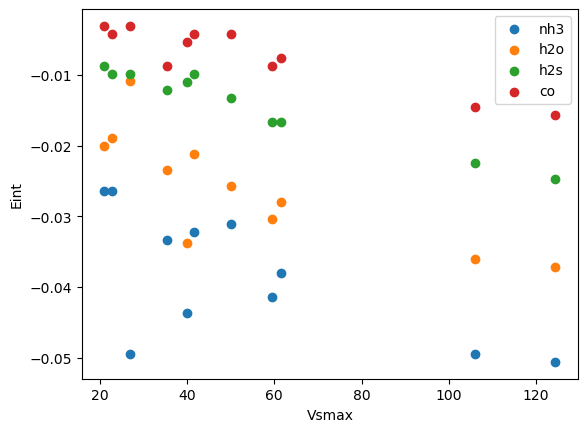

In [18]:
plt.figure()

for ads in ads_list:
    plt.scatter(df_tot["Vsmax"], df_tot[ads], label=ads)

plt.legend()
plt.xlabel("Vsmax")
plt.ylabel("Eint")
plt.show()

